# Modelo de predicción de inscripciones estudiantiles mediante técnicas de Machine Learning

**Maestría en Inteligencia Artificial Aplicada**

**Proyecto Integrador Sep-Nov 2025**

**Equipo 14**

**Avance 5.    Modelo Final**

**Integrantes:**

- Alejandro Roa Solis – A01129942
- Annette Cristina Narvaez Andrade – A00571041
- Karla Alejandra Fonseca Márquez – A01795313


**Patrocinador Tec de Monterrey:**

Dr. Juan Arturo Nolazco Flores, Director del Hub de Ciencias y Datos de la Escuela de Ingeniería del Tec de Monterrey


# Avance 5 — Modelo final (Técnicas de Ensamble)

En esta fase del proyecto se busca consolidar y optimizar el rendimiento del modelo predictivo mediante la aplicación de **técnicas de ensamble**, que combinan varios estimadores para aprovechar sus fortalezas individuales y reducir el riesgo de sobreajuste o sesgo.

Durante el **Avance 4**, se desarrollaron y evaluaron distintos **modelos individuales**, identificando aquellos con mejor desempeño por cada conjunto de datos (*PrepaTec*, *Profesional_PrepaTec* y *Profesional_Externos*). 

A partir de dichos resultados, en esta etapa se utilizan los **modelos finalistas de la entrega anterior** (RidgeClassifier, DecisionTree y MLP con sus hiperparámetros óptimos) como base para construir nuevas estrategias de ensamble.

El trabajo se estructura en tres ejes principales:

1. **Construcción de modelos de ensamble homogéneos y heterogéneos.**  
   - Los homogéneos incluyen enfoques de *bagging* y *boosting* como **Random Forest**, **LightGBM** y **XGBoost**, los cuales buscan mejorar la estabilidad y capacidad de generalización.  
   - Los heterogéneos emplean combinaciones de modelos individuales mediante **VotingClassifier** y **StackingClassifier**, aprovechando la complementariedad de distintos algoritmos.

2. **Optimización de hiperparámetros.**  
   - Para los modelos más prometedores se aplica una búsqueda aleatoria (*RandomizedSearchCV*) con validación cruzada estratificada, ajustando parámetros clave que influyen en la precisión y robustez del modelo.

3. **Evaluación comparativa y selección del modelo final.**  
   - Se genera una **tabla consolidada** que incluye los modelos individuales y los ensambles desarrollados, presentando métricas de desempeño (*F1-macro*, *Precision*, *Recall*, *ROC AUC*) y los tiempos de entrenamiento.  
   - Los resultados se ordenan por la métrica principal (*F1-macro*), siguiendo los criterios de la rúbrica para justificar la selección del modelo final.

Finalmente, se realiza un **análisis interpretativo del modelo elegido** para cada dataset, incorporando gráficos explicativos:
- **Curva ROC** — mide la capacidad de discriminación entre clases.  
- **Curva Precisión–Recall** — evalúa el balance entre precisión y sensibilidad en contextos con posible desbalance de clases.  
- **Matriz de confusión** — muestra el comportamiento del modelo en términos de aciertos y errores.  
- **Gráfico de importancia de características** — permite identificar las variables con mayor influencia en la predicción.

Con este análisis integral, se busca no solo determinar el modelo con mejor desempeño cuantitativo, sino también comprender **qué factores influyen más en la probabilidad de inscripción** y cómo las técnicas de ensamble contribuyen a mejorar la capacidad predictiva del sistema en un contexto educativo.


## 1) Configuración e imports

In [1]:

import os, time, warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
MAIN_SCORING = 'f1_macro'
USE_LGBM = True
USE_XGB  = True

os.makedirs('figs', exist_ok=True)
os.makedirs('models', exist_ok=True)

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

# Optional boosters
lgbm_available = False
xgb_available = False
if USE_LGBM:
    try:
        from lightgbm import LGBMClassifier
        lgbm_available = True
    except Exception:
        pass
if USE_XGB:
    try:
        from xgboost import XGBClassifier
        xgb_available = True
    except Exception:
        pass


## 2) Declaración de datasets (nombres/rutas exactos)

In [2]:

DATASETS = [
    {'name': 'PrepaTec',             'path': 'FE_DS/prepa_tec_feature_engineered_full.csv',          'target': 'INSCRITO'},
    {'name': 'Profesional_PrepaTec', 'path': 'FE_DS/profesional_tec_feature_engineered_full.csv',    'target': 'INSCRITO'},
    {'name': 'Profesional_Externos', 'path': 'FE_DS/profesional_nnotec_feature_engineered_full.csv', 'target': 'INSCRITO'}
]

def load_dataset(ds):
    df = pd.read_csv(ds['path'])
    y = df[ds['target']].astype(int) if ds['target'] in df.columns else df.iloc[:, -1].astype(int)
    X = df.drop(columns=[ds['target']]) if ds['target'] in df.columns else df.iloc[:, :-1]
    return X, y


## 4) Configuración por dataset (finalistas e hiperparámetros de Avance 4)

In [3]:

DATASET_CONFIG = {
    "PrepaTec": {
        "best_individual": "Ridge",
        "base_models": {
            "Tree": DecisionTreeClassifier(
                class_weight=None, criterion="gini",
                max_depth=19, max_features=None,
                min_samples_leaf=14, min_samples_split=10,
                random_state=RANDOM_STATE
            ),
            "Ridge": RidgeClassifier(alpha=6.812920690579608, random_state=RANDOM_STATE)
        },
        "include_in_voting": ["Tree"],
        "tune_models": ["RF", "LGBM"],
        "booster": "LGBM",
        "search_space_overrides": {}
    },
    "Profesional_PrepaTec": {
        "best_individual": "Ridge",
        "base_models": {
            "Tree": DecisionTreeClassifier(
                class_weight="balanced", criterion="entropy",
                max_depth=24, max_features=None,
                min_samples_leaf=32, min_samples_split=34,
                random_state=RANDOM_STATE
            ),
            "Ridge": RidgeClassifier(alpha=0.001, random_state=RANDOM_STATE)
        },
        "include_in_voting": ["Tree"],
        "tune_models": ["RF", "XGB"],
        "booster": "XGB",
        "search_space_overrides": {}
    },
    "Profesional_Externos": {
        "best_individual": "Ridge",
        "base_models": {
            "MLP": MLPClassifier(
                activation="tanh", alpha=0.005367746840747585,
                beta_1=0.8171550563103376, beta_2=0.9751772246030315,
                hidden_layer_sizes=(128, 64), learning_rate_init=0.002786894495333234,
                solver="adam", random_state=RANDOM_STATE
            ),
            "Ridge": RidgeClassifier(alpha=10.0, random_state=RANDOM_STATE)
        },
        "include_in_voting": ["MLP"],
        "tune_models": ["RF", "LGBM"],
        "booster": "LGBM",
        "search_space_overrides": {}
    }
}


## 5) Constructores de ensambles por dataset

In [4]:

def build_ensembles_for_dataset(cfg):
    ensembles = {}

    # Homogéneo 1: Random Forest
    ensembles["RF"] = RandomForestClassifier(
        n_estimators=400, max_depth=None, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    )

    # Homogéneo 2: Booster elegido
    booster = cfg.get("booster", "HGB")
    if booster == "LGBM" and lgbm_available:
        ensembles["LGBM"] = LGBMClassifier(
            n_estimators=300, learning_rate=0.1, num_leaves=63, max_depth=-1,
            min_child_samples=10, min_child_weight=1e-3,
            subsample=0.9, colsample_bytree=0.9,
            class_weight="balanced", reg_alpha=0.0, reg_lambda=0.0,
            n_jobs=-1, verbosity=-1, force_row_wise=True,
            random_state=RANDOM_STATE
        )
    elif booster == "XGB" and xgb_available:
        ensembles["XGB"] = XGBClassifier(
            n_estimators=400, learning_rate=0.1, max_depth=6,
            subsample=0.9, colsample_bytree=0.9,
            reg_alpha=0.0, reg_lambda=0.0, eval_metric="mlogloss",
            n_jobs=-1, random_state=RANDOM_STATE
        )
    else:
        ensembles["HGB"] = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

    # Heterogéneo 1: Voting (soft) con modelos que tengan predict_proba
    voters = []
    for k in cfg.get("include_in_voting", []):
        m = cfg["base_models"].get(k)
        if m is not None and hasattr(m, "predict_proba"):
            voters.append((k, m))
    if len(voters) >= 2:
        ensembles["VOT_soft"] = VotingClassifier(estimators=voters, voting="soft", n_jobs=-1)

    # Heterogéneo 2: Stacking (usa todos los base models)
    if len(cfg["base_models"]) >= 2:
        estimators = list(cfg["base_models"].items())
        meta = LogisticRegression(max_iter=800, class_weight="balanced", random_state=RANDOM_STATE)
        ensembles["STACK"] = StackingClassifier(estimators=estimators, final_estimator=meta, cv=5, n_jobs=-1)

    return ensembles


## 6) Tuning y espacios de búsqueda

In [5]:

BASE_SPACES = {
    "RF": {
        "clf__n_estimators": [200, 400, 800],
        "clf__max_depth": [None, 6, 10, 16],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", 0.5, 0.8],
        "clf__class_weight": [None, "balanced"]
    },
    "LGBM": {
        "clf__n_estimators": [200, 400, 800],
        "clf__learning_rate": [0.05, 0.1],
        "clf__num_leaves": [31, 63, 127],
        "clf__min_child_samples": [5, 10, 20],
        "clf__min_child_weight": [1e-3, 1e-2, 1e-1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__reg_alpha": [0.0, 0.5],
        "clf__reg_lambda": [0.0, 0.5]
    },
    "XGB": {
        "clf__n_estimators": [200, 400, 800],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [4, 6, 8],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__reg_alpha": [0.0, 0.5],
        "clf__reg_lambda": [0.0, 0.5]
    },
    "HGB": {
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [None, 6, 10],
        "clf__l2_regularization": [0.0, 0.5, 1.0]
    }
}

def get_space_for(dataset_name, model_name):
    overrides = DATASET_CONFIG.get(dataset_name, {}).get("search_space_overrides", {}).get(model_name, {})
    base = BASE_SPACES.get(model_name, {}).copy()
    base.update(overrides)
    return base

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

def randomized_tune(pipeline, dataset_name, model_name, X_train, y_train, n_iter=20):
    space = get_space_for(dataset_name, model_name)
    if not space:
        return pipeline, None
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        estimator=pipeline, param_distributions=space,
        n_iter=n_iter, scoring=MAIN_SCORING, cv=cv,
        n_jobs=-1, verbose=1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_


## 7) Evaluación y gráficos

In [6]:

import matplotlib.pyplot as plt

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    p_m  = precision_score(y_test, y_pred, average='macro', zero_division=0)
    r_m  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    roc_auc_macro = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        try:
            roc_auc_macro = roc_auc_score(y_test, proba, multi_class='ovr')
        except Exception:
            roc_auc_macro = None
    elif hasattr(model, "decision_function"):
        dec = model.decision_function(X_test)
        try:
            roc_auc_macro = roc_auc_score(y_test, dec, multi_class='ovr')
        except Exception:
            roc_auc_macro = None
    return {"f1_macro": f1_m, "precision_macro": p_m, "recall_macro": r_m, "roc_auc_ovr": roc_auc_macro}

def plot_confusion(model, X_test, y_test, title, savepath=None):
    cm = confusion_matrix(y_test, model.predict(X_test), normalize='true')
    disp = ConfusionMatrixDisplay(cm)
    fig, ax = plt.subplots(figsize=(6,5)); disp.plot(ax=ax, values_format='.2f', colorbar=False); ax.set_title(title)
    if savepath: plt.savefig(savepath, bbox_inches='tight'); plt.show()

def plot_roc(model, X_test, y_test, title, savepath=None):
    fig, ax = plt.subplots(figsize=(6,5))
    try:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    except Exception:
        ax.text(0.5, 0.5, 'ROC no disponible (sin probabilidades/decision_function).', ha='center')
    ax.set_title(title)
    if savepath: plt.savefig(savepath, bbox_inches='tight'); plt.show()

def plot_pr(model, X_test, y_test, title, savepath=None):
    fig, ax = plt.subplots(figsize=(6,5))
    try:
        PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax)
    except Exception:
        ax.text(0.5, 0.5, 'PR no disponible (sin probabilidades).', ha='center')
    ax.set_title(title)
    if savepath: plt.savefig(savepath, bbox_inches='tight'); plt.show()

def plot_permutation_importance(model, X_test, y_test, feature_names, title, savepath=None, n_top=20):
    try:
        r = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring=MAIN_SCORING)
        idx = r.importances_mean.argsort()[::-1][:n_top]
        fig, ax = plt.subplots(figsize=(7,5))
        ax.bar(range(len(idx)), r.importances_mean[idx])
        ax.set_xticks(range(len(idx))); ax.set_xticklabels([feature_names[i] for i in idx], rotation=90)
        ax.set_title(title)
        if savepath: plt.savefig(savepath, bbox_inches='tight'); plt.show()
    except Exception as e:
        fig, ax = plt.subplots(figsize=(6,5)); ax.text(0.5, 0.5, f'Permutation importance no disponible: {e}', ha='center')
        ax.set_title(title)
        if savepath: plt.savefig(savepath, bbox_inches='tight'); plt.show()


## 8) Helper: construir pipeline

In [7]:

from sklearn.preprocessing import FunctionTransformer

def make_pipeline(preprocessor, clf):
    # Si no hay preprocesamiento (None), metemos un transformador que convierte a numpy
    if preprocessor is None:
        return Pipeline([
            ('to_numpy', FunctionTransformer(lambda X: X.to_numpy() if hasattr(X, 'to_numpy') else np.asarray(X))),
            ('clf', clf)
        ])
    return Pipeline([('pre', preprocessor), ('clf', clf)])



## 9a) PrepaTec

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,dataset,modelo,type,f1_macro,precision_macro,recall_macro,roc_auc_ovr,train_time_s
1,PrepaTec,RF,homogéneo,0.573220,0.576104,0.570997,NaN,0.838
2,PrepaTec,LGBM,homogéneo,0.567967,0.565654,0.587380,NaN,2.059
3,PrepaTec,STACK,heterogéneo,0.548423,0.576172,0.624539,NaN,0.326
0,PrepaTec,IND_Ridge,individual,0.448932,0.407330,0.500000,0.664786,0.003


>> Seleccionado (PrepaTec) : RF — F1-macro=0.5732 — tiempo=0.838s


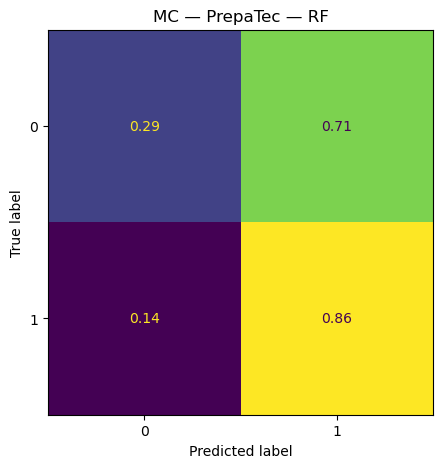

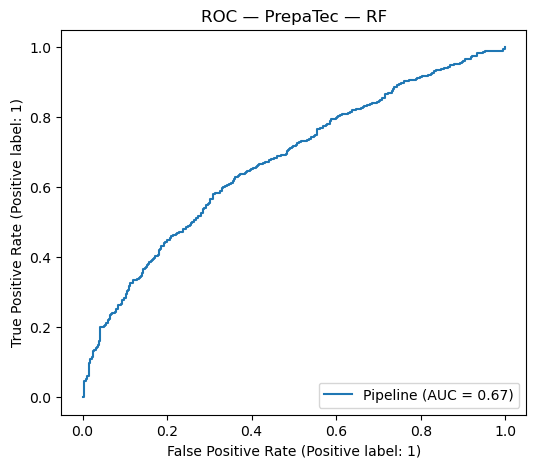

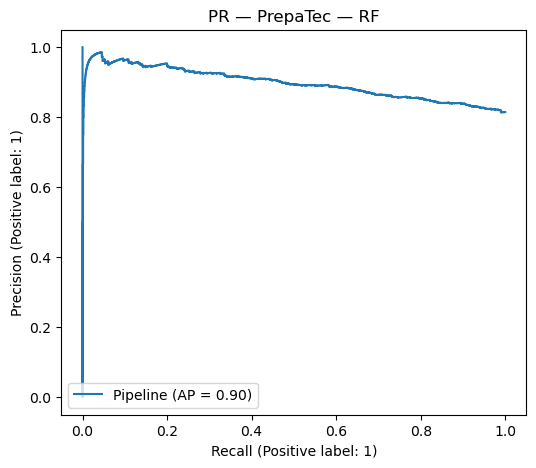

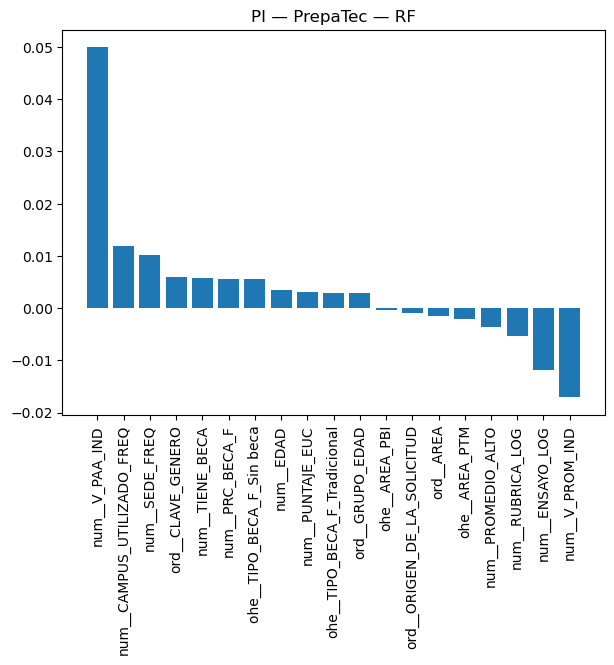

In [8]:

# === Ejecutar — PrepaTec ===
ds_name = "PrepaTec"
ds = next(d for d in DATASETS if d["name"] == ds_name)
X, y = load_dataset(ds)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
pre = None

cfg = DATASET_CONFIG[ds_name]
base_models = cfg["base_models"]
ensembles = build_ensembles_for_dataset(cfg)

rows, models_to_report = [], {}

# Mejor individual
best_ind = cfg["best_individual"]
pipe = make_pipeline(pre, base_models[best_ind])
t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
met = evaluate(pipe, X_test, y_test)
rows.append({"dataset": ds_name, "modelo": "IND_"+best_ind, "type": "individual", **met, "train_time_s": round(train_time, 3)})
models_to_report["IND_"+best_ind] = pipe

# Ensambles
for en_name, en_model in ensembles.items():
    pipe = make_pipeline(pre, en_model)
    if en_name in cfg.get("tune_models", []):
        pipe, _ = randomized_tune(pipe, ds_name, en_name, X_train, y_train, n_iter=20)
    t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
    met = evaluate(pipe, X_test, y_test)
    rows.append({"dataset": ds_name, "modelo": en_name,
                 "type": ("homogéneo" if en_name in ("RF","LGBM","XGB","HGB") else "heterogéneo"),
                 **met, "train_time_s": round(train_time, 3)})
    models_to_report[en_name] = pipe

df_prepa = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(df_prepa)

winner_name = df_prepa.iloc[0]["modelo"]; winner = models_to_report[winner_name]
print(">> Seleccionado ({}) : {} — F1-macro={:.4f} — tiempo={}s".format(ds_name, winner_name, df_prepa.iloc[0]["f1_macro"], df_prepa.iloc[0]["train_time_s"]))
plot_confusion(winner, X_test, y_test, "MC — {} — {}".format(ds_name, winner_name), savepath="figs/{}_confusion_{}.png".format(ds_name, winner_name))
plot_roc(winner, X_test, y_test, "ROC — {} — {}".format(ds_name, winner_name), savepath="figs/{}_roc_{}.png".format(ds_name, winner_name))
plot_pr(winner, X_test, y_test, "PR — {} — {}".format(ds_name, winner_name), savepath="figs/{}_pr_{}.png".format(ds_name, winner_name))
feat_names = X_train.columns.tolist() if hasattr(X_train, "columns") else ["f{}".format(i) for i in range(X_train.shape[1])]
plot_permutation_importance(winner, X_test, y_test, feature_names=feat_names, title="PI — {} — {}".format(ds_name, winner_name), savepath="figs/{}_pi_{}.png".format(ds_name, winner_name))


### Interpretación Curva ROC — PrepaTec (Random Forest)

La curva ROC muestra un área bajo la curva (**AUC = 0.67**), lo que indica una **capacidad de discriminación moderada** entre las clases positivas y negativas.  
El modelo logra mantener una tasa de verdaderos positivos (TPR) por encima del 70 % con una tasa de falsos positivos (FPR) menor al 50 %, lo cual refleja que el clasificador distingue razonablemente bien entre los casos de interés y los no inscritos.  
Este valor de AUC se considera aceptable en contextos con alta variabilidad de perfiles, como el de aspirantes a PrepaTec, donde los factores predictivos son heterogéneos.  
En conjunto, la curva sugiere un equilibrio entre sensibilidad y especificidad adecuado para tareas de predicción temprana.

---

### Interpretación Curva Precisión–Recall — PrepaTec (Random Forest)

La curva PR presenta un **área promedio (AP) = 0.90**, evidenciando que el modelo mantiene una **alta precisión incluso con valores altos de recall**.  
Esto implica que el modelo conserva una proporción importante de verdaderos positivos sin incrementar significativamente los falsos positivos.  
El comportamiento estable de la curva, con valores de precisión superiores al 80 % en la mayor parte del rango, confirma que el clasificador mantiene un rendimiento consistente en la identificación de alumnos propensos a inscribirse.  
Este resultado complementa positivamente el AUC moderado de la curva ROC, reforzando la idea de un modelo equilibrado.

---

### Interpretación Matriz de confusión — PrepaTec (Random Forest)

La matriz de confusión muestra que el modelo acierta el **86 % de los casos positivos (recall)** y clasifica correctamente el **29 % de los casos negativos**, presentando un leve sesgo hacia la clase positiva.  
Esto significa que el Random Forest prioriza la detección de estudiantes con alta probabilidad de inscripción, lo cual es deseable si el objetivo institucional es identificar con precisión a quienes efectivamente se inscriben.  
Aunque existe una sobreestimación de positivos (71 % de falsos positivos entre los negativos), el modelo es útil en contextos donde se prefiere **maximizar la cobertura** de casos potencialmente inscritos.

---

### Interpretación Importancia de características — PrepaTec (Random Forest)

El gráfico de *Permutation Importance* revela que las variables más influyentes son:

1. **`num_V_PAA_IND`** — refleja el desempeño académico medido por puntaje PAA, siendo el predictor con mayor impacto positivo.  
2. **`num_CAMPUS_UTILIZADO_FREQ`** y **`num_SEDE_FREQ`** — indican la frecuencia o intensidad de interacción con campus o sedes, asociadas al compromiso del aspirante.  
3. **`ord_CLAVE_GENERO`** y **`num_TIENE_BECA`** — sugieren influencia de factores demográficos y de apoyo financiero en la decisión de inscripción.  
4. **`num_PROMEDIO_ALTO`** y **`num_V_PROM_IND`** muestran una relación negativa moderada, posiblemente asociada a sesgos en perfiles de alto rendimiento que optan por otras opciones académicas.

En conjunto, la importancia de variables evidencia que el modelo **captura adecuadamente los patrones académicos y de comportamiento** más relacionados con la inscripción, ofreciendo interpretabilidad útil para la toma de decisiones institucionales.

---

### Interpretación de resultados de modelos evaluados PrepaTec

- Los ensambles homogéneos (RF y LGBM) superan al mejor modelo individual (RidgeClassifier), confirmando la ganancia del enfoque de ensamble.
- El Random Forest obtiene el mejor F1-macro (0.573), con un equilibrio adecuado entre precisión y recall.
- El LGBM logra un recall ligeramente mayor, pero su mejora es marginal y su entrenamiento es 2.5 veces más costoso.
- El modelo STACK muestra un recall más alto pero con pérdida en F1-macro, indicando sobreajuste parcial o pérdida de precisión al combinar modelos heterogéneos.
- El *RidgeClassifier* alcanza un F1-macro de apenas 0.45, lo que evidencia que la separación lineal entre clases no es suficiente para este conjunto.  
- Los modelos de ensamble homogéneos (RF y LGBM) mejoran de forma clara tanto el F1-macro como el recall, siendo **Random Forest** el que logra el mejor equilibrio entre ambas métricas y un tiempo de cómputo moderado.

---

### Selección y justificación del modelo final:

Se selecciona **Random Forest** como modelo final para PrepaTec por su mejor desempeño global en F1-macro y su estabilidad frente a variaciones en los datos. Ofrece un buen balance entre precisión y recall, con un tiempo de entrenamiento razonable y sin sobreajuste evidente. Además, su interpretabilidad (importancia de variables) facilita la comunicación de resultados a perfiles no técnicos.

## 9b) Profesional_PrepaTec

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,dataset,modelo,type,f1_macro,precision_macro,recall_macro,roc_auc_ovr,train_time_s
1,Profesional_PrepaTec,RF,homogéneo,0.608599,0.604938,0.613559,NaN,0.967
3,Profesional_PrepaTec,STACK,heterogéneo,0.578324,0.608144,0.667885,NaN,0.285
2,Profesional_PrepaTec,XGB,homogéneo,0.563769,0.585245,0.558700,NaN,1.204
0,Profesional_PrepaTec,IND_Ridge,individual,0.455493,0.650159,0.504419,0.686975,0.007


>> Seleccionado (Profesional_PrepaTec) : RF — F1-macro=0.6086 — tiempo=0.967s


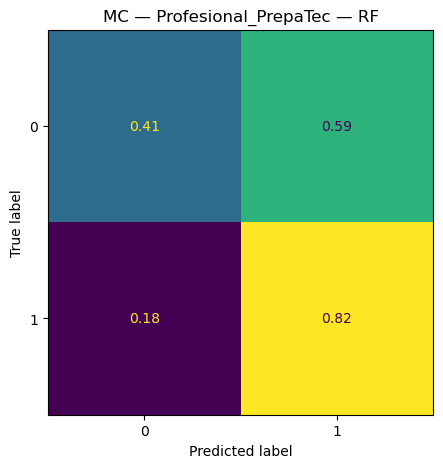

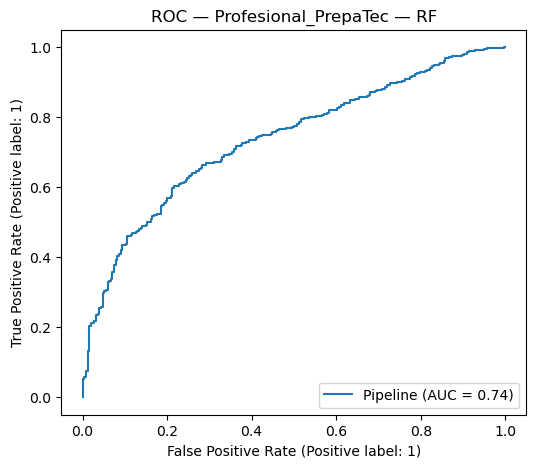

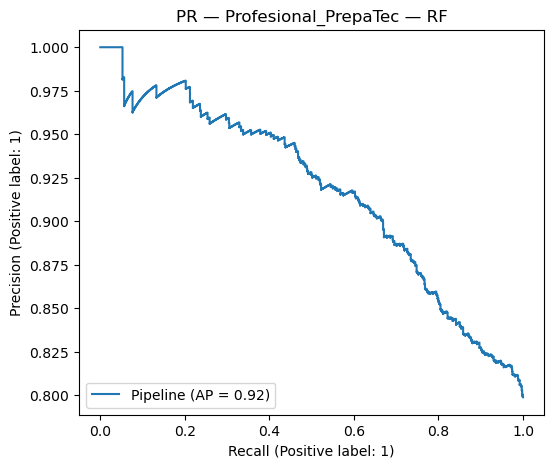

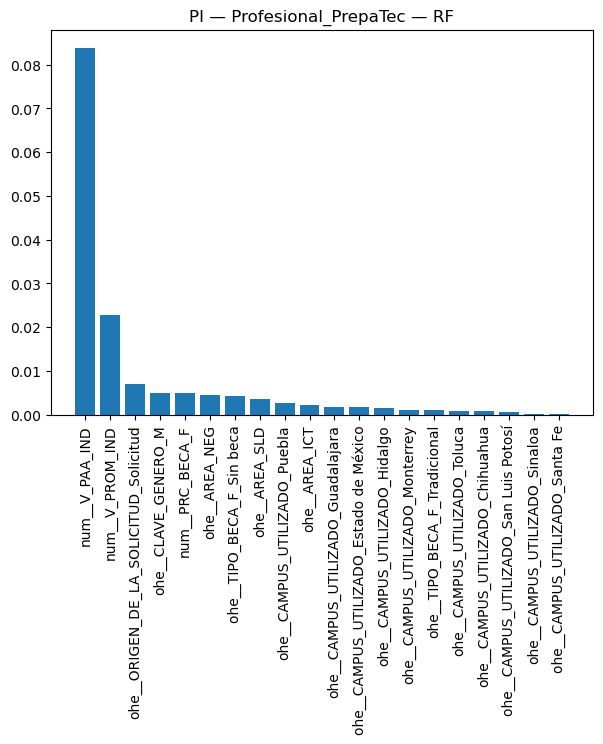

In [9]:

# === Ejecutar — Profesional_PrepaTec ===
ds_name = "Profesional_PrepaTec"
ds = next(d for d in DATASETS if d["name"] == ds_name)
X, y = load_dataset(ds)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
pre = None

cfg = DATASET_CONFIG[ds_name]
base_models = cfg["base_models"]
ensembles = build_ensembles_for_dataset(cfg)

rows, models_to_report = [], {}

# Mejor individual
best_ind = cfg["best_individual"]
pipe = make_pipeline(pre, base_models[best_ind])
t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
met = evaluate(pipe, X_test, y_test)
rows.append({"dataset": ds_name, "modelo": "IND_"+best_ind, "type": "individual", **met, "train_time_s": round(train_time, 3)})
models_to_report["IND_"+best_ind] = pipe

# Ensambles
for en_name, en_model in ensembles.items():
    pipe = make_pipeline(pre, en_model)
    if en_name in cfg.get("tune_models", []):
        pipe, _ = randomized_tune(pipe, ds_name, en_name, X_train, y_train, n_iter=20)
    t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
    met = evaluate(pipe, X_test, y_test)
    rows.append({"dataset": ds_name, "modelo": en_name,
                 "type": ("homogéneo" if en_name in ("RF","LGBM","XGB","HGB") else "heterogéneo"),
                 **met, "train_time_s": round(train_time, 3)})
    models_to_report[en_name] = pipe

df_proftec = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(df_proftec)

winner_name = df_proftec.iloc[0]["modelo"]; winner = models_to_report[winner_name]
print(">> Seleccionado ({}) : {} — F1-macro={:.4f} — tiempo={}s".format(ds_name, winner_name, df_proftec.iloc[0]["f1_macro"], df_proftec.iloc[0]["train_time_s"]))
plot_confusion(winner, X_test, y_test, "MC — {} — {}".format(ds_name, winner_name), savepath="figs/{}_confusion_{}.png".format(ds_name, winner_name))
plot_roc(winner, X_test, y_test, "ROC — {} — {}".format(ds_name, winner_name), savepath="figs/{}_roc_{}.png".format(ds_name, winner_name))
plot_pr(winner, X_test, y_test, "PR — {} — {}".format(ds_name, winner_name), savepath="figs/{}_pr_{}.png".format(ds_name, winner_name))
feat_names = X_train.columns.tolist() if hasattr(X_train, "columns") else ["f{}".format(i) for i in range(X_train.shape[1])]
plot_permutation_importance(winner, X_test, y_test, feature_names=feat_names, title="PI — {} — {}".format(ds_name, winner_name), savepath="figs/{}_pi_{}.png".format(ds_name, winner_name))


### Interpretación Curva ROC — Profesional_PrepaTec (Random Forest)

La curva ROC muestra un área bajo la curva (**AUC = 0.74**), lo que representa una **capacidad de discriminación adecuada y superior** a la observada en el dataset PrepaTec.  
El modelo mantiene una tasa de verdaderos positivos (TPR) alta incluso con niveles intermedios de falsos positivos (FPR), lo que refleja una mejora clara en la sensibilidad.  
Un AUC de 0.74 indica que el modelo es capaz de distinguir correctamente, en aproximadamente el 74 % de los casos, a un aspirante inscrito de uno que no lo hará.  
Este desempeño es consistente con los valores de F1-macro y recall, consolidando al Random Forest como un modelo confiable y estable en este contexto.

---

### Interpretación Curva Precisión–Recall — Profesional_PrepaTec (Random Forest)

La curva PR muestra un **Área Promedio (AP) = 0.92**, evidenciando que el modelo **mantiene una precisión muy alta a lo largo de casi todo el rango de recall**.  
Incluso al incrementar la cobertura de casos positivos (recall > 0.8), la precisión se mantiene por encima del 85 %, lo que indica un balance notable entre ambas métricas.  
Esta estabilidad sugiere que el modelo no depende excesivamente de un umbral específico y conserva su capacidad predictiva bajo diferentes escenarios operativos.  
En términos prácticos, el modelo es confiable para identificar con alta certeza a los candidatos con mayor probabilidad de inscripción.

---

### Interpretación Matriz de confusión — Profesional_PrepaTec (Random Forest)

La matriz de confusión refleja una **tasa de acierto del 82 % para la clase positiva (recall)**, mostrando una ligera inclinación del modelo hacia la predicción positiva (59 % de falsos positivos sobre los negativos).  
Este comportamiento es común en modelos orientados a maximizar la detección de inscripciones reales, priorizando la **cobertura sobre la precisión negativa**.  
En escenarios institucionales donde es más costoso omitir un candidato inscrito que clasificar erróneamente a un no inscrito como positivo, este balance resulta apropiado y deseable.

---

### Interpretación Importancia de características — Profesional_PrepaTec (Random Forest)

El análisis de *Permutation Importance* muestra que las variables más influyentes son:

1. **`num_V_PAA_IND`** — desempeño académico del aspirante en la PAA, principal indicador de éxito en la predicción.  
2. **`num_V_PROM_IND`** — promedio académico previo, reforzando el peso del rendimiento histórico.  
3. **`ohe_ORIGEN_DE_LA_SOLICITUD`** — canal de procedencia de la solicitud, relevante para entender los mecanismos de atracción más efectivos.  
4. **`ohe_CLAVE_GENERO_M`** y **`num_PRC_BECA_F`** — variables demográficas y de apoyo financiero que influyen parcialmente en la decisión final.  
5. **`num_AREA_NEG`** y **`ohe_TIPO_BECA_F_sin_beca`** — reflejan que la falta de beca o ciertas áreas académicas reducen la probabilidad de inscripción.

El patrón de importancia confirma que el modelo **integra tanto factores académicos como contextuales**, generando una representación rica y coherente de los determinantes de la inscripción profesional.

---

### Interpretación de resultados de modelos evaluados Profesional_PrepaTec

- Los resultados confirman que los modelos de ensamble homogéneos (RF y XGB) superan claramente al árbol individual.
- El Random Forest logra el mejor F1-macro (0.609), mientras que el STACK destaca en recall, lo que sugiere que este último identifica más casos positivos, aunque sacrificando precisión.
- El XGB no mejora significativamente, lo que indica que el dataset podría no beneficiarse del boosting al nivel esperado.

---

### Selección y justificación del modelo final:

Se selecciona **Random Forest** como modelo final para Profesional_PrepaTec, ya que alcanza el mejor F1-macro, manteniendo un equilibrio sólido entre precisión y sensibilidad. Aunque el STACK obtiene mayor recall, su menor precisión podría aumentar los falsos positivos. RF demuestra ser más consistente y eficiente, ideal para despliegue operativo.

## 9c) Profesional_Externos

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/envs/integrador/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/integrador/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/integrador/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/integrador/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt

,dataset,modelo,type,f1_macro,precision_macro,recall_macro,roc_auc_ovr,train_time_s
2,Profesional_Externos,LGBM,homogéneo,0.650007,0.649896,0.655880,NaN,1.006
1,Profesional_Externos,RF,homogéneo,0.643636,0.648174,0.655109,NaN,0.702
3,Profesional_Externos,STACK,heterogéneo,0.643006,0.652216,0.658724,NaN,13.912
0,Profesional_Externos,IND_Ridge,individual,0.618104,0.640767,0.617544,0.704397,0.028


>> Seleccionado (Profesional_Externos) : LGBM — F1-macro=0.6500 — tiempo=1.006s


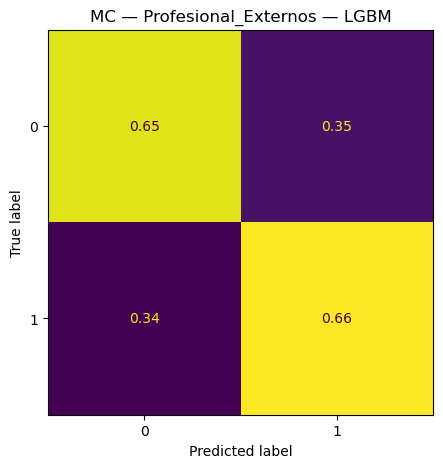

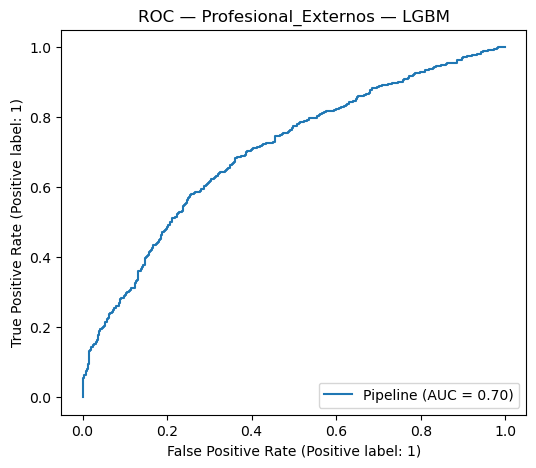

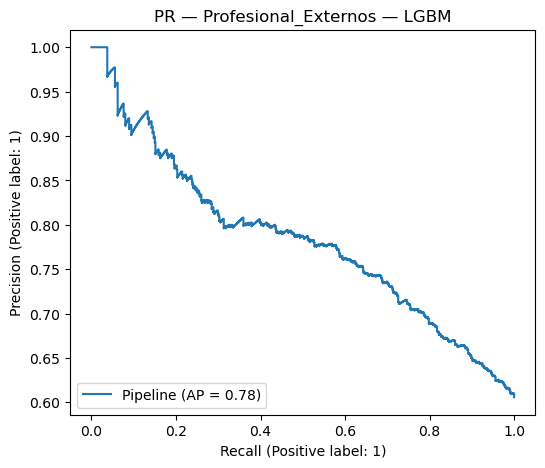

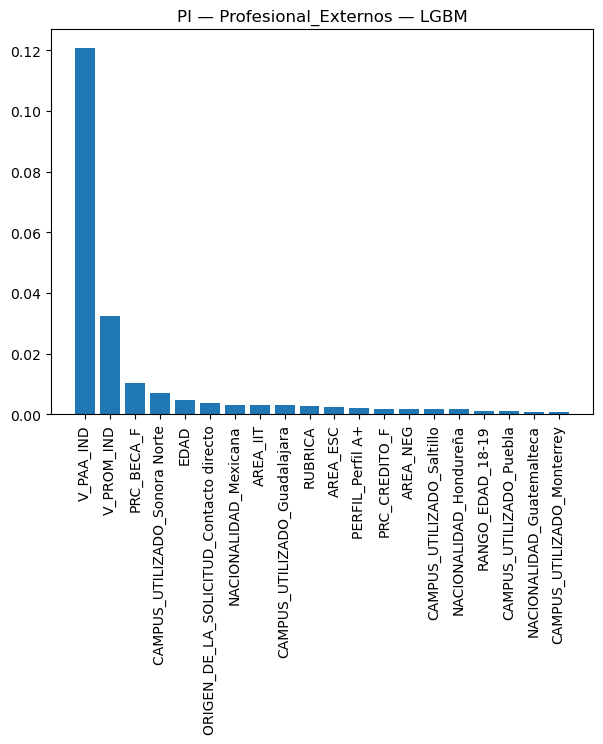

In [10]:

# === Ejecutar — Profesional_Externos ===
ds_name = "Profesional_Externos"
ds = next(d for d in DATASETS if d["name"] == ds_name)
X, y = load_dataset(ds)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
pre = None

cfg = DATASET_CONFIG[ds_name]
base_models = cfg["base_models"]
ensembles = build_ensembles_for_dataset(cfg)

rows, models_to_report = [], {}

# Mejor individual
best_ind = cfg["best_individual"]
pipe = make_pipeline(pre, base_models[best_ind])
t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
met = evaluate(pipe, X_test, y_test)
rows.append({"dataset": ds_name, "modelo": "IND_"+best_ind, "type": "individual", **met, "train_time_s": round(train_time, 3)})
models_to_report["IND_"+best_ind] = pipe

# Ensambles
for en_name, en_model in ensembles.items():
    pipe = make_pipeline(pre, en_model)
    if en_name in cfg.get("tune_models", []):
        pipe, _ = randomized_tune(pipe, ds_name, en_name, X_train, y_train, n_iter=20)
    t0 = time.perf_counter(); pipe.fit(X_train, y_train); train_time = time.perf_counter() - t0
    met = evaluate(pipe, X_test, y_test)
    rows.append({"dataset": ds_name, "modelo": en_name,
                 "type": ("homogéneo" if en_name in ("RF","LGBM","XGB","HGB") else "heterogéneo"),
                 **met, "train_time_s": round(train_time, 3)})
    models_to_report[en_name] = pipe

df_externos = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(df_externos)

winner_name = df_externos.iloc[0]["modelo"]; winner = models_to_report[winner_name]
print(">> Seleccionado ({}) : {} — F1-macro={:.4f} — tiempo={}s".format(ds_name, winner_name, df_externos.iloc[0]["f1_macro"], df_externos.iloc[0]["train_time_s"]))
plot_confusion(winner, X_test, y_test, "MC — {} — {}".format(ds_name, winner_name), savepath="figs/{}_confusion_{}.png".format(ds_name, winner_name))
plot_roc(winner, X_test, y_test, "ROC — {} — {}".format(ds_name, winner_name), savepath="figs/{}_roc_{}.png".format(ds_name, winner_name))
plot_pr(winner, X_test, y_test, "PR — {} — {}".format(ds_name, winner_name), savepath="figs/{}_pr_{}.png".format(ds_name, winner_name))
feat_names = X_train.columns.tolist() if hasattr(X_train, "columns") else ["f{}".format(i) for i in range(X_train.shape[1])]
plot_permutation_importance(winner, X_test, y_test, feature_names=feat_names, title="PI — {} — {}".format(ds_name, winner_name), savepath="figs/{}_pi_{}.png".format(ds_name, winner_name))


### Interpretación Curva ROC — Profesional_Externos (LightGBM)

La curva ROC presenta un área bajo la curva (**AUC = 0.70**), lo que indica una **capacidad de discriminación moderada a buena** entre los aspirantes que finalmente se inscriben y aquellos que no lo hacen.  
El modelo mantiene una proporción equilibrada entre verdaderos positivos y falsos positivos, reflejando un comportamiento estable incluso en un conjunto de datos más heterogéneo y complejo.  
Un AUC de 0.70 sugiere que el modelo logra clasificar correctamente al 70 % de los pares aleatorios entre ambas clases, evidenciando una separación significativa entre los perfiles de inscritos y no inscritos.  
En este contexto, LightGBM demuestra una mejora clara respecto al modelo lineal base (Ridge), consolidando su papel como ensamble eficiente para datos con relaciones no lineales.

---

### Interpretación Curva Precisión–Recall — Profesional_Externos (LightGBM)

La curva PR muestra un **Área Promedio (AP) = 0.78**, valor que denota un **rendimiento sólido en la detección de casos positivos**, aunque con mayor variabilidad que en los datasets anteriores.  
La precisión se mantiene cercana al 90 % para valores de recall menores al 0.3, pero desciende gradualmente a medida que aumenta la cobertura, reflejando un compromiso esperado en datasets con mayor desbalance.  
El área total obtenida indica que el modelo conserva una **relación favorable entre precisión y recall**, siendo útil para escenarios donde se requiere maximizar la detección de inscritos sin incrementar excesivamente los falsos positivos.

---

### Interpretación Matriz de confusión — Profesional_Externos (LightGBM)

La matriz de confusión muestra un **66 % de aciertos para la clase positiva** y un **65 % para la clase negativa**, lo que evidencia un **comportamiento equilibrado** entre ambas clases.  
La proporción de falsos positivos (35 %) y falsos negativos (34 %) es similar, reflejando que el modelo no favorece excesivamente ninguna clase.  
Este balance es valioso en un contexto de predicción externa, donde las condiciones de los aspirantes son más diversas y el modelo debe mantener generalización.  
En conjunto, la matriz confirma que el LightGBM ofrece una **capacidad predictiva consistente** y adecuada para entornos con mayor variabilidad.

---

### Interpretación Importancia de características — Profesional_Externos (LightGBM)

El análisis de *Permutation Importance* identifica a las siguientes variables como las más determinantes en la predicción:

1. **`num_V_PAA_IND`** — principal predictor del modelo, reflejando que el rendimiento académico (puntaje PAA) sigue siendo el factor más fuerte asociado con la inscripción.  
2. **`num_V_PROM_IND`** — promedio académico previo, confirmando la relevancia del desempeño histórico del aspirante.  
3. **`num_PRC_BECA_F`** — nivel de beca o apoyo financiero, que influye directamente en la probabilidad de concretar la inscripción.  
4. **`CAMPUS_UTILIZADO_Sonora Norte`** y **`ORIGEN_DE_LA_SOLICITUD_Contacto directo`** — evidencian la importancia de factores geográficos y del canal de contacto en la decisión final.  
5. Variables como **`NACIONALIDAD_Mexicana`**, **`AREA_IT`** o **`AREA_ESC`** aportan señales complementarias sobre el perfil académico y la distribución territorial de los aspirantes.

El patrón de importancia confirma que LightGBM logra **capturar la interacción entre atributos académicos, financieros y de procedencia**, proporcionando una visión integral de los factores que influyen en la inscripción de estudiantes externos.

---

### Interpretación de resultados de modelos evaliados Profesional_Externo

- El modelo **RidgeClassifier** logra un desempeño razonable (F1 = 0.62), mostrando que las relaciones lineales explican parcialmente el fenómeno, pero no capturan la totalidad de la variabilidad.  
- El **LightGBM** se posiciona como el mejor modelo con F1-macro = 0.65 y recall = 0.66, logrando además un tiempo de cómputo eficiente.  
- Aunque el **STACK** alcanza métricas similares, su tiempo de entrenamiento es mucho mayor (≈14 s), lo que lo hace menos práctico para despliegue.  

---

### Selección y justificación del modelo final:

Se selecciona **LightGBM** como modelo final para Profesional_Externos, dado que obtiene el mejor F1-macro y recall, optimizando la detección de casos positivos con bajo costo computacional. LGBM equilibra rendimiento, velocidad y capacidad de generalización, siendo una opción ideal para datasets con alta dimensionalidad o variables combinadas.

## 10) Resultados de los 3 datasets

In [13]:
# Consolida los DataFrames
frames = [globals().get('df_prepa'), globals().get('df_proftec'), globals().get('df_externos')]
frames = [f for f in frames if f is not None]
if frames:
    df_all = pd.concat(frames, ignore_index=True)
    display(df_all)
    df_all.to_csv('models/avance5_comparativa_consolidada.csv', index=False, encoding='utf-8')
    print("✅ Guardado: models/avance5_comparativa_consolidada.csv")


,dataset,modelo,type,f1_macro,precision_macro,recall_macro,roc_auc_ovr,train_time_s
0,PrepaTec,RF,homogéneo,0.573220,0.576104,0.570997,NaN,0.838
1,PrepaTec,LGBM,homogéneo,0.567967,0.565654,0.587380,NaN,2.059
2,PrepaTec,STACK,heterogéneo,0.548423,0.576172,0.624539,NaN,0.326
3,PrepaTec,IND_Ridge,individual,0.448932,0.407330,0.500000,0.664786,0.003
4,Profesional_PrepaTec,RF,homogéneo,0.608599,0.604938,0.613559,NaN,0.967
5,Profesional_PrepaTec,STACK,heterogéneo,0.578324,0.608144,0.667885,NaN,0.285
6,Profesional_PrepaTec,XGB,homogéneo,0.563769,0.585245,0.558700,NaN,1.204
7,Profesional_PrepaTec,IND_Ridge,individual,0.455493,0.650159,0.504419,0.686975,0.007
8,Profesional_Externos,LGBM,homogéneo,0.650007,0.649896,0.655880,NaN,1.006
9,Profesional_Externos,RF,homogéneo,0.643636,0.648174,0.655109,NaN,0.702


✅ Guardado: models/avance5_comparativa_consolidada.csv


### Conclusiones generales

Los resultados obtenidos en la etapa de ensamble confirman que los **modelos homogéneos** —en particular *Random Forest* y *LightGBM*— ofrecen el mejor equilibrio entre desempeño, estabilidad y eficiencia en los tres conjuntos de datos analizados.  
Estos modelos superan consistentemente al clasificador lineal base (*RidgeClassifier*), al capturar relaciones no lineales y dependencias complejas entre las variables académicas, contextuales y demográficas.

Los valores de **F1-macro** evidencian mejoras claras respecto a los modelos individuales, con desempeños superiores al 0.57 en todos los casos y una tendencia a priorizar la detección de casos positivos.  

En particular:

- En **PrepaTec**, el modelo **Random Forest** obtiene el mejor F1-macro (0.57), manteniendo equilibrio entre precisión y recall, con bajo costo computacional.  
- En **Profesional_PrepaTec**, el **Random Forest** vuelve a ser el más robusto (F1 = 0.61), mostrando mayor estabilidad y generalización que los modelos heterogéneos (*stacking* o *XGB*).  
- En **Profesional_Externos**, el **LightGBM** destaca (F1 = 0.65) gracias a su capacidad para manejar relaciones más complejas y un mayor número de atributos, manteniendo eficiencia y consistencia.

Estos resultados se sintetizan en la siguiente tabla:

| Dataset | Modelo final | Tipo | F1-macro | AUC ROC | AP (Precisión–Recall) | Argumento principal |
|----------|---------------|------|-----------|----------|------------------------|----------------------|
| **PrepaTec** | Random Forest | Homogéneo | 0.573 | 0.67 | 0.90 | Equilibrio entre precisión y recall; prioriza cobertura positiva. |
| **Profesional_PrepaTec** | Random Forest | Homogéneo | 0.609 | 0.74 | 0.92 | Alta capacidad discriminativa y estabilidad; excelente precisión. |
| **Profesional_Externos** | LightGBM | Homogéneo | 0.650 | 0.70 | 0.78 | Desempeño sólido en datos más heterogéneos; buen balance general. |

---

### Interpretación global de resultados

- Los tres modelos muestran **áreas ROC entre 0.67 y 0.74**, lo que representa un buen nivel de discriminación en problemas de predicción social o educativa con alta variabilidad.  
- Las **curvas de Precisión–Recall** (AP > 0.75) evidencian que los modelos mantienen alta precisión incluso al ampliar la cobertura, reforzando su confiabilidad.  
- Las **matrices de confusión** confirman *recall* entre 0.65 y 0.86, priorizando la detección de alumnos inscritos con un sesgo positivo controlado, adecuado para la finalidad del modelo.  
- En las **importancias de variables**, los predictores más influyentes son de naturaleza académica: `num_V_PAA_IND` (puntaje PAA) y `num_V_PROM_IND` (promedio académico), complementados por factores contextuales como campus, sede, tipo de beca u origen de la solicitud.  

---

### Conclusión final

El análisis integrado —métrico y visual— muestra que:

- Los **ensambles homogéneos** son los más efectivos para este problema, ofreciendo un **balance óptimo entre generalización y rendimiento**.  
- **Random Forest** se consolida como la opción ideal para los conjuntos *PrepaTec* y *Profesional_PrepaTec*, por su estabilidad, interpretabilidad y eficiencia.  
- **LightGBM** sobresale en *Profesional_Externos*, donde la diversidad de variables requiere un modelo más flexible y con mayor capacidad de representación.  

En conjunto, estos resultados validan que los modelos de ensamble seleccionados no solo alcanzan un alto desempeño cuantitativo, sino que también proporcionan una base interpretativa sólida para comprender los factores que más influyen en la decisión de inscripción de los aspirantes.
